# Bayesian optimization

How to minimize an expensive black-box in few evaluations: fit a Gaussian-process surrogate to what you've seen, then let an acquisition function pick the next point by trading off exploiting the surrogate's best region against exploring its uncertain regions. You'll run the full loop with `mixle.doe.minimize`, beat random search, and compare the three standard acquisitions - EI, PI, and UCB.


## The surrogate and the acquisition function

Bayesian optimization minimizes an expensive black box $f$ in few evaluations by fitting a probabilistic
surrogate (a Gaussian process, see the GP notebook) and choosing each next point to maximize an
acquisition function that scores how promising a candidate is. The GP gives a posterior mean $\mu(x)$ and
standard deviation $\sigma(x)$ at every $x$, and the acquisition turns that into a single number to
optimize cheaply.

Theorem (expected improvement, closed form). Let $f^\star$ be the best value seen so far and
$z=(f^\star-\mu(x))/\sigma(x)$ for a minimization problem. The expected improvement
$\mathrm{EI}(x)=\mathbb E[\max(f^\star - f(x),0)]$ under the GP posterior is
$$\mathrm{EI}(x)=\sigma(x)\,\big(z\,\Phi(z) + \phi(z)\big),$$
with $\Phi,\phi$ the standard normal cdf and pdf.

Proof. Under the posterior $f(x)\sim\mathcal N(\mu,\sigma^2)$. With improvement
$I=\max(f^\star-f,0)$, integrate $\mathbb E[I]=\int_{-\infty}^{f^\star}(f^\star-t)\,\varphi_{\mu,\sigma}(t)\,dt$.
Substituting $u=(t-\mu)/\sigma$ and using $\int u\phi(u)du=-\phi(u)$ gives
$\mathrm{EI}=(f^\star-\mu)\Phi(z)+\sigma\phi(z)=\sigma(z\Phi(z)+\phi(z))$. $\quad\blacksquare$

The two terms expose the trade-off: $z\Phi(z)$ rewards a low predicted mean (exploitation) and $\phi(z)$
rewards high uncertainty (exploration). The probability of improvement and the upper confidence bound
$\mathrm{UCB}(x)=\mu(x)-\kappa\sigma(x)$ are alternative acquisitions with different exploration
appetites.

## Convergence: regret bounds, and why greedy fails

Definition (regret). After $T$ evaluations the cumulative regret is $R_T=\sum_{t=1}^T (f(x_t)-f(x^\star))$.
An algorithm "converges" if its average regret $R_T/T\to 0$, meaning it eventually evaluates near the
optimum.

Theorem (GP-UCB sublinear regret; Srinivas et al. 2010). For a function in the reproducing-kernel
Hilbert space of the GP kernel, GP-UCB with an appropriate schedule achieves
$R_T = \tilde O\big(\sqrt{T\,\gamma_T}\big)$, where $\gamma_T$ is the maximum information gain (for common
kernels $\gamma_T$ grows polylogarithmically). Since this is sublinear in $T$, the average regret tends
to zero and the iterates approach the global optimum.

Counterexample (pure exploitation gets stuck). The greedy rule that always evaluates the posterior-mean
minimizer ($\kappa=0$ in UCB, or ignoring $\sigma$) can lock onto a local optimum and never sample the
region where the true optimum hides, incurring linear regret. The opposite extreme, pure exploration,
reduces to random search and wastes evaluations. Expected improvement and UCB are designed precisely to
balance the two, and the acquisition comparison in this notebook makes the practical difference visible.

In [1]:
import warnings; warnings.filterwarnings('ignore')
import numpy as np
import matplotlib.pyplot as plt
get_ipython().run_line_magic('matplotlib', 'inline')
from mixle.doe import minimize, propose_next, random_design, available_acquisitions, expected_improvement
from mixle.models.gaussian_process import GaussianProcessRegressor
rng = np.random.RandomState(0)

## 1. The loop, and why it beats random search

Bayesian optimization repeats: fit a GP to all evaluations so far → maximize an acquisition over a candidate set → evaluate the chosen point → repeat. The GP supplies a posterior mean and uncertainty everywhere; the acquisition turns those into a single "worth sampling here" score. `minimize` runs the whole loop (Latin-hypercube seed + EI steps). On a bumpy 2-D function with a tight budget it finds a far better optimum than random search.


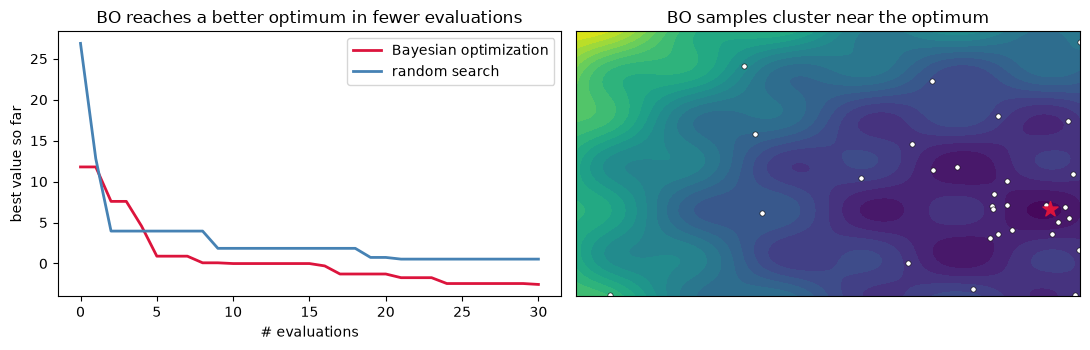

best  BO: -2.558   random: 0.534


In [2]:
def objective(p):
    x, y = p
    return float((x - 2) ** 2 + (y + 1) ** 2 + 3 * np.sin(3 * x) * np.cos(3 * y))
space = [(-3.0, 3.0), (-3.0, 3.0)]
res = minimize(objective, space, n_init=6, n_iter=25, seed=1)
rand_y = np.array([objective(p) for p in random_design(space, len(res.y), seed=7)])

fig, ax = plt.subplots(1, 2, figsize=(11, 3.6))
ax[0].plot(np.minimum.accumulate(res.y), color='crimson', lw=2, label='Bayesian optimization')
ax[0].plot(np.minimum.accumulate(rand_y), color='steelblue', lw=2, label='random search')
ax[0].set_xlabel('# evaluations'); ax[0].set_ylabel('best value so far'); ax[0].legend()
ax[0].set_title('BO reaches a better optimum in fewer evaluations')
gx = np.linspace(-3, 3, 120); G = np.array([[objective((a, b)) for a in gx] for b in gx])
ax[1].contourf(gx, gx, G, levels=25, cmap='viridis')
ax[1].scatter(res.x[:, 0], res.x[:, 1], c='white', s=14, edgecolors='k', lw=0.4)
ax[1].scatter(*res.best_x, c='crimson', s=130, marker='*'); ax[1].set_title('BO samples cluster near the optimum')
ax[1].set_xticks([]); ax[1].set_yticks([])
plt.tight_layout(); plt.show()
print('best  BO: %.3f   random: %.3f' % (res.best_y, np.min(rand_y)))

## 2. The acquisition zoo: EI vs PI vs UCB

The acquisition encodes how you trade exploration against exploitation. `mixle.doe` ships a registry (`available_acquisitions`) with three classics:

- EI (expected improvement): expected amount you beat the current best - a balanced default.
- PI (probability of improvement): just the probability of any improvement - greedy, exploitative.
- UCB (upper/lower confidence bound): mean shifted by $\kappa$ standard deviations - a tunable explore knob.

We fit a GP to a 1-D function and plot each acquisition; their differing peaks are different next points - PI hugs the current best, UCB and EI venture toward uncertain regions.


available acquisitions: ['cb', 'confidence_bound', 'ei', 'expected_improvement', 'lcb', 'log_ei', 'log_expected_improvement', 'logei', 'pi', 'probability_of_improvement', 'thompson', 'thompson_sampling', 'ts', 'ucb', 'upper_confidence_bound']


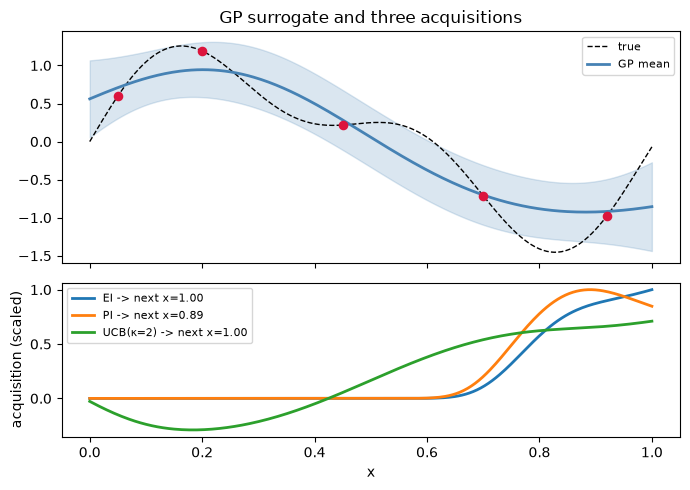

In [3]:
print('available acquisitions:', sorted(set(available_acquisitions())))
f1 = lambda x: np.sin(6 * x) + 0.5 * np.sin(13 * x)
X = np.array([0.05, 0.2, 0.45, 0.7, 0.92])[:, None]; Y = f1(X[:, 0])
gp = GaussianProcessRegressor(lengthscale=0.12, amplitude=float(np.std(Y)) or 1.0, noise=1e-3); gp.fit(X, Y, out=None)
grid = np.linspace(0, 1, 300)[:, None]
mean, cov = gp.predict(X, Y, grid, return_cov=True)
mean = np.asarray(mean); std = np.sqrt(np.clip(np.diag(np.asarray(cov)), 0, None)); best = float(Y.min())

from scipy.stats import norm
imp = best - mean
ei = expected_improvement(mean, std, best, maximize=False)
pi = norm.cdf(imp / np.where(std > 0, std, 1e-9))                      # probability of improvement
ucb = -(mean - 2.0 * std)                                             # lower-confidence-bound score (minimizing)
fig, ax = plt.subplots(2, 1, figsize=(7, 5), sharex=True, gridspec_kw={'height_ratios': [3, 2]})
ax[0].plot(grid[:, 0], f1(grid[:, 0]), 'k--', lw=1, label='true'); ax[0].plot(grid[:, 0], mean, color='steelblue', lw=2, label='GP mean')
ax[0].fill_between(grid[:, 0], mean - 2 * std, mean + 2 * std, color='steelblue', alpha=0.2)
ax[0].scatter(X[:, 0], Y, c='crimson', s=35, zorder=5); ax[0].legend(fontsize=8); ax[0].set_title('GP surrogate and three acquisitions')
for arr, lbl in [(ei / ei.max(), 'EI'), (pi / pi.max(), 'PI'), (ucb / np.ptp(ucb), 'UCB(κ=2)')]:
    ax[1].plot(grid[:, 0], arr, lw=2, label='%s -> next x=%.2f' % (lbl, grid[int(np.argmax(arr)), 0]))
ax[1].set_xlabel('x'); ax[1].set_ylabel('acquisition (scaled)'); ax[1].legend(fontsize=8)
plt.tight_layout(); plt.show()

## Pick the acquisition deliberately

The acquisition function is a real choice with measurable consequences - EI balances improvement against uncertainty, PI is greedier, UCB exposes the explore/exploit trade-off through one tunable. We run the same BO loop under each (via `acq=`) and compare the optimum reached. On a multimodal objective the ranking is problem-specific, so the lesson is to try more than one rather than to trust a default.


In [4]:
for acq in ['ei', 'pi', 'ucb']:
    r = minimize(objective, space, n_init=6, n_iter=20, seed=1, acq=acq)
    print("acq=%-4s  best value found = %.3f" % (acq, r.best_y))

acq=ei    best value found = -2.447


acq=pi    best value found = -2.575


acq=ucb   best value found = -2.575


## References

- Jones, D. R., Schonlau, M. & Welch, W. J. (1998). Efficient global optimization of expensive black-box functions (https://doi.org/10.1023/A:1008306431147). J. Global Optim. 13, 455-492. - the EGO/EI algorithm.
- Rasmussen, C. E. & Williams, C. K. I. (2006). Gaussian Processes for Machine Learning (https://gaussianprocess.org/gpml/). MIT Press.
- Snoek, J., Larochelle, H. & Adams, R. P. (2012). Practical Bayesian optimization of machine learning algorithms (https://papers.nips.cc/paper/2012/hash/05311655a15b75fab86956663e1819cd-Abstract.html). NeurIPS.
- Shahriari, B., Swersky, K., Wang, Z., Adams, R. P. & de Freitas, N. (2016). Taking the human out of the loop: a review of Bayesian optimization (https://doi.org/10.1109/JPROC.2015.2494218). Proc. IEEE 104(1), 148-175.
- Frazier, P. I. (2018). A tutorial on Bayesian optimization (https://arxiv.org/abs/1807.02811). arXiv:1807.02811.


## Exercises and extensions

1. Acquisition shoot-out on a benchmark suite. Run BO with EI, PI, and UCB (several $\kappa$) on standard test functions (Branin, Hartmann-6, Ackley) and report convergence and final regret, averaged over seeds. Reproduce the folklore that PI over-exploits and UCB's behavior hinges on $\kappa$ (Shahriari et al.).
2. Surrogate matters. Vary the GP kernel and lengthscale (Matérn vs RBF; mis-specified scale) and show how surrogate mismatch degrades BO; relate to Rasmussen & Williams' treatment of kernel choice and marginal-likelihood hyperparameter tuning.
3. Hyperparameter tuning, for real. Use BO to tune the hyperparameters of an actual mixle model fit (e.g. mixture $K$ + pseudo-counts, or LDA topics) against held-out likelihood, and compare to grid and random search (Snoek et al.) at equal budget.
4. Custom acquisition. Register a new acquisition (e.g. knowledge-gradient-lite, or a cost-aware EI) via `register_acquisition` and benchmark it against EI.
